Dados carregados. Shape inicial: (96992, 18)
Linhas após filtro de status: 58232

Distribuição do alvo (NoShow):
NoShow
0    52152
1     6080
Name: count, dtype: int64

Sessões bônus (eh_bonus=1): 4426
Taxa de desmarcação – bônus vs. pagas:
eh_bonus
0    0.0991
1    0.1688
Name: NoShow, dtype: float64

Convênios com < 30 atendimentos removidos: []
Linhas após remoção de convênios raros: 58232

Exemplo de features históricas:
             nome_paciente           date_time      status  NoShow  \
0   Carlos Roberto Martins 2026-04-06 14:00:00    atendido       0   
1   Carlos Roberto Martins 2026-04-07 10:00:00    atendido       0   
2   Carlos Roberto Martins 2026-04-14 15:00:00    atendido       0   
3   Carlos Roberto Martins 2026-04-16 09:00:00    atendido       0   
4   Carlos Roberto Martins 2026-04-21 09:00:00    atendido       0   
5   Carlos Roberto Martins 2026-04-23 10:00:00    atendido       0   
6   Carlos Roberto Martins 2026-04-28 14:00:00    atendido       0   
7   Carlos 

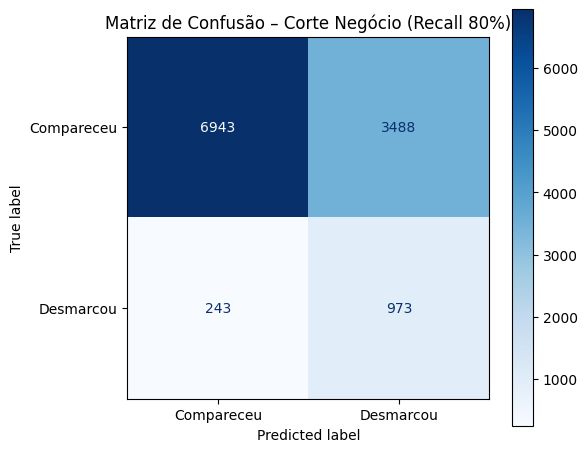

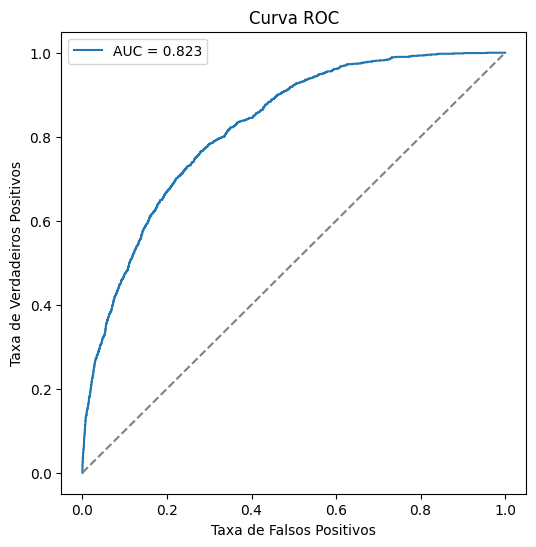


✅ Modelo exportado como 'no_show_model_v3.pkl'

--- FIM DO SCRIPT ---


In [2]:
# =============================================================================
# MODELO DE PREVISÃO DE NO-SHOW – REGRESSÃO LOGÍSTICA (Versão Simplificada)
# =============================================================================
# Alterações em relação à versão anterior:
# 1. Removeu a suavização bayesiana (usa patient_noshow_rate_past direto)
# 2. Reinseriu eh_bonus e valor_servico como features
# 3. Mantém modelo enxuto (sem tem_pacote) pois a base não possui essa info
# =============================================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve
from sklearn.linear_model import LogisticRegressionCV
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve
import warnings
warnings.filterwarnings('ignore')

# -----------------------------------------------------------------------------
# 1. CARREGAMENTO DOS DADOS
# -----------------------------------------------------------------------------
df = pd.read_csv("/content/drive/MyDrive/freela habilis/agendamentos_limpo.csv", encoding='utf-8-sig')
print("Dados carregados. Shape inicial:", df.shape)

# -----------------------------------------------------------------------------
# 2. PRÉ-PROCESSAMENTO E LIMPEZA
# -----------------------------------------------------------------------------
df['data_agendamento'] = pd.to_datetime(df['data_agendamento'], errors='coerce')
df['hora_inicio'] = pd.to_datetime(df['hora_inicio'], format='%H:%M:%S', errors='coerce').dt.time
df['date_time'] = df.apply(lambda row: pd.Timestamp.combine(row['data_agendamento'].date(), row['hora_inicio']), axis=1)
df = df.dropna(subset=['date_time', 'nome_paciente']).copy()
df['hora'] = df['date_time'].dt.hour

status_validos = ['atendido', 'desmarcado', 'falta']
df = df[df['status'].str.lower().isin(status_validos)].copy()
print(f"Linhas após filtro de status: {len(df)}")

def to_noshow(status):
    if pd.isna(status):
        return 0
    return 1 if "desmarc" in str(status).strip().lower() else 0

df["NoShow"] = df["status"].apply(to_noshow)
print("\nDistribuição do alvo (NoShow):")
print(df["NoShow"].value_counts())

# -----------------------------------------------------------------------------
# 3. VALOR DO SERVIÇO E FLAG BÔNUS
# -----------------------------------------------------------------------------
df["valor_servico"] = (
    df["nome_procedimento"]
    .astype(str)
    .str.extract(r"(\d{1,3}(?:\.\d{3})*,\d{2}|\d+,\d{2}|\d+)")[0]
    .str.replace(".", "", regex=False)
    .str.replace(",", ".", regex=False)
    .astype(float)
)

df["eh_bonus"] = df["valor_servico"].isna().astype(int)
df["valor_servico"] = df["valor_servico"].fillna(0)
df["eh_bonus"] = (
    (df["eh_bonus"] == 1) |
    (df["nome_procedimento"].str.lower().str.contains("bônus|bonus", na=False))
).astype(int)
df.loc[df["eh_bonus"] == 1, "valor_servico"] = 0

print("\nSessões bônus (eh_bonus=1):", int(df["eh_bonus"].sum()))
print("Taxa de desmarcação – bônus vs. pagas:")
print(df.groupby("eh_bonus")["NoShow"].mean().round(4))

# -----------------------------------------------------------------------------
# 4. REMOÇÃO DE CONVÊNIOS RAROS
# -----------------------------------------------------------------------------
volume_conv = df["nome_convenio"].value_counts()
LIMIAR_CONV = 30
convenios_raros = volume_conv[volume_conv < LIMIAR_CONV].index.tolist()
print(f"\nConvênios com < {LIMIAR_CONV} atendimentos removidos: {convenios_raros}")
df = df[~df["nome_convenio"].isin(convenios_raros)].copy()
print(f"Linhas após remoção de convênios raros: {len(df)}")

# -----------------------------------------------------------------------------
# 5. FEATURE ENGINEERING
# -----------------------------------------------------------------------------
df["dia_semana"] = df["date_time"].dt.day_name().map({
    "Monday": "Segunda", "Tuesday": "Terça", "Wednesday": "Quarta",
    "Thursday": "Quinta", "Friday": "Sexta", "Saturday": "Sábado", "Sunday": "Domingo"
})

df["faixa_horaria"] = pd.cut(
    df["hora"],
    bins=[-0.1, 4.9, 11.9, 17.9, 23.9],
    labels=["Madrugada", "Manhã", "Tarde", "Noite"]
)

df = df.sort_values(["nome_paciente", "date_time"]).reset_index(drop=True)

# Features históricas (SEM suavização bayesiana)
df["patient_total_appointments_past"] = df.groupby("nome_paciente").cumcount()

df["patient_noshow_count_past"] = (
    df.groupby("nome_paciente")["NoShow"]
    .transform(lambda s: s.shift(1).fillna(0).cumsum())
)

df["patient_noshow_rate_past"] = np.where(
    df["patient_total_appointments_past"] > 0,
    df["patient_noshow_count_past"] / df["patient_total_appointments_past"],
    0
)

def rolling_30d_noshow(group):
    group = group.sort_values("date_time")
    result = (
        group.set_index("date_time")["NoShow"]
        .rolling("30D").sum().shift(1).fillna(0)
    )
    result.index = group.index
    return result

df["patient_noshow_last_30d"] = (
    df.groupby("nome_paciente", group_keys=False)
    .apply(rolling_30d_noshow)
    .reset_index(level=0, drop=True)
)

def create_noshow_streak(group):
    group = group.sort_values("date_time").copy()
    streak = 0
    streak_list = []
    for _, row in group.iterrows():
        streak_list.append(streak)
        if row["NoShow"] == 1:
            streak += 1
        else:
            streak = 0
    group["patient_noshow_streak"] = streak_list
    return group

df = df.groupby("nome_paciente", group_keys=False).apply(create_noshow_streak)

# Verificação amostral
cols_check = [
    "nome_paciente", "date_time", "status", "NoShow",
    "patient_total_appointments_past", "patient_noshow_count_past",
    "patient_noshow_rate_past",
    "patient_noshow_last_30d", "patient_noshow_streak"
]
print("\nExemplo de features históricas:")
print(df[cols_check].head(10))

# -----------------------------------------------------------------------------
# 6. SELEÇÃO DE FEATURES
# -----------------------------------------------------------------------------
# Features contextuais (agora com eh_bonus e valor_servico)
features_num_ctx = ["valor_servico", "eh_bonus"]
features_cat = ["dia_semana", "faixa_horaria", "nome_convenio"]

features_num_hist = [
    "patient_total_appointments_past",
    "patient_noshow_rate_past",  # ← SEM suavização bayesiana
    "patient_noshow_last_30d",
    "patient_noshow_streak",
]

features_num = features_num_ctx + features_num_hist

df = df.dropna(subset=["faixa_horaria", "dia_semana", "nome_convenio"]).copy()

X_raw = df[features_num + features_cat].copy()
y = df["NoShow"].copy()

print("\nShape da matriz de features:", X_raw.shape)
print("Distribuição do alvo (proporção):")
print(y.value_counts(normalize=True).round(4))

# One-hot encoding
X = pd.get_dummies(X_raw, columns=features_cat, drop_first=True)
X = X.astype(float)
print(f"Features finais (após dummy): {X.shape[1]} colunas.")

# Tratar NaNs/Inf
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)
print("NaN restantes:", int(X.isna().sum().sum()))

# -----------------------------------------------------------------------------
# 7. DIVISÃO TREINO/TESTE
# -----------------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTamanho do treino: {len(X_train)} | Teste: {len(X_test)}")
print(f"Taxa base de no-show no treino: {y_train.mean():.4f}")

ponto_corte_base = y_train.mean()

# -----------------------------------------------------------------------------
# 8. MODELO STATSMODELS (com todas as features)
# -----------------------------------------------------------------------------
X_train_sm_const = sm.add_constant(X_train)
X_test_sm_const = sm.add_constant(X_test)
X_test_sm_const = X_test_sm_const.reindex(columns=X_train_sm_const.columns, fill_value=0)

modelo_sm = sm.Logit(y_train, X_train_sm_const).fit(method="bfgs", maxiter=1000, disp=False)
print("\n--- Resumo do modelo statsmodels ---")
print(modelo_sm.summary())

prob_sm = modelo_sm.predict(X_test_sm_const)

# -----------------------------------------------------------------------------
# 9. DEFINIÇÃO DA FUNÇÃO DE CORTE
# -----------------------------------------------------------------------------
def corte_para_recall(y_true, prob, recall_alvo):
    precisions, recalls, thresholds = precision_recall_curve(y_true, prob)
    precisions, recalls = precisions[:-1], recalls[:-1]
    ok = recalls >= recall_alvo
    if not ok.any():
        return None, None, None
    idx_candidatos = np.where(ok)[0]
    idx = idx_candidatos[np.argmax(precisions[idx_candidatos])]
    return thresholds[idx], precisions[idx], recalls[idx]

RECALL_ALVO = 0.80
corte_biz, prec_biz, rec_biz = corte_para_recall(y_test, prob_sm, RECALL_ALVO)
print(f"\n--- Corte de negócio (recall-alvo = {RECALL_ALVO:.0%}) ---")
print(f"Corte: {corte_biz:.4f} | Recall: {rec_biz:.3f} | Precisão: {prec_biz:.3f}")

# Classificações
y_pred_base = (prob_sm >= ponto_corte_base).astype(int)
y_pred_biz = (prob_sm >= corte_biz).astype(int)

# Corte ótimo de F1
def melhor_corte_f1(y_true, prob):
    precisions, recalls, thresholds = precision_recall_curve(y_true, prob)
    precisions, recalls = precisions[:-1], recalls[:-1]
    f1s = np.where((precisions+recalls)>0,
                   2*precisions*recalls/(precisions+recalls+1e-9), 0)
    idx = np.argmax(f1s)
    return thresholds[idx], f1s[idx], precisions[idx], recalls[idx]

corte_f1, f1_opt, prec_f1, rec_f1 = melhor_corte_f1(y_test, prob_sm)
y_pred_f1 = (prob_sm >= corte_f1).astype(int)

# -----------------------------------------------------------------------------
# 10. RELATÓRIOS COMPARATIVOS
# -----------------------------------------------------------------------------
print("\n" + "="*60)
print("RELATÓRIOS DE CLASSIFICAÇÃO")
print("="*60)

print("\n>>> CORTE BASE (taxa base = {:.3f})".format(ponto_corte_base))
print(classification_report(y_test, y_pred_base, digits=3))
print("Matriz de confusão:\n", confusion_matrix(y_test, y_pred_base))

print("\n>>> CORTE DE NEGÓCIO (recall-alvo = {:.0%})".format(RECALL_ALVO))
print(classification_report(y_test, y_pred_biz, digits=3))
print("Matriz de confusão:\n", confusion_matrix(y_test, y_pred_biz))

print("\n>>> CORTE ÓTIMO DE F1")
print(classification_report(y_test, y_pred_f1, digits=3))
print("Matriz de confusão:\n", confusion_matrix(y_test, y_pred_f1))

# -----------------------------------------------------------------------------
# 11. VALIDAÇÃO CRUZADA
# -----------------------------------------------------------------------------
modelo_cv = LogisticRegressionCV(
    Cs=10, cv=5, penalty='l2', solver='lbfgs',
    class_weight='balanced', max_iter=2000
)
modelo_cv.fit(X_train, y_train)
prob_cv = modelo_cv.predict_proba(X_test)[:,1]
auc_cv = roc_auc_score(y_test, prob_cv)
print(f"\nAUC do modelo com validação cruzada: {auc_cv:.4f}")

# -----------------------------------------------------------------------------
# 12. VISUALIZAÇÕES
# -----------------------------------------------------------------------------
# Matriz de confusão com corte de negócio
cm_biz = confusion_matrix(y_test, y_pred_biz)
fig, ax = plt.subplots(figsize=(6,5))
disp = ConfusionMatrixDisplay(cm_biz, display_labels=["Compareceu", "Desmarcou"])
disp.plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title(f"Matriz de Confusão – Corte Negócio (Recall {RECALL_ALVO:.0%})")
plt.tight_layout()
plt.show()

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, prob_sm)
fig, ax = plt.subplots(figsize=(6,6))
ax.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, prob_sm):.3f}")
ax.plot([0,1],[0,1], '--', color='gray')
ax.set_xlabel("Taxa de Falsos Positivos")
ax.set_ylabel("Taxa de Verdadeiros Positivos")
ax.set_title("Curva ROC")
ax.legend()
plt.show()

# -----------------------------------------------------------------------------
# 13. EXPORTAÇÃO DO MODELO
# -----------------------------------------------------------------------------
import joblib

# Salvar o modelo statsmodels e as colunas
joblib.dump({
    'modelo': modelo_sm,
    'colunas': X_train_sm_const.columns.tolist(),
    'ponto_corte_base': ponto_corte_base,
    'corte_negocio': corte_biz,
    'media_global': y_train.mean(),
    'alpha_suavizacao': 10,  # mantido para compatibilidade
}, "no_show_model_v3.pkl")

print("\n✅ Modelo exportado como 'no_show_model_v3.pkl'")
print("\n--- FIM DO SCRIPT ---")